# 01 — Data Preparation

This notebook loads the 2024 ACS person-level data for California.

The dataset used in this project comes from the 2024 American Community Survey Public Use Microdata Sample (ACS PUMS), made available by the U.S. Census Bureau. PUMS files contain untabulated records about individual people and housing units, allowing researchers to create custom analyses beyond pretabulated ACS tables. This project uses ACS person-level data to build a predictive employment model and examine how demographic, educational, disability-related, household, and service-related variables shape model predictions. Because the data reflect real labor-market and social patterns, they provide a useful setting for studying biased algorithmic decision-making, proxy variables, and the limits of removing protected attributes from predictive models.


## 1. Install packages

For anyone trying to reproduce thsi notebook:

Run this cell if you are using Google Colab or a fresh local environment.

If you are running locally and already installed the requirements, you can skip this cell.

In [1]:
!pip install -q folktables shap lime scikit-learn pandas numpy matplotlib

## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from folktables import ACSDataSource, ACSEmployment

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [3]:
from pathlib import Path

# Save figures

FIGURE_DIR = Path("../figures")
if not FIGURE_DIR.parent.exists():
    FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

POSTER_BLUE = "#0393DB"
POSTER_ORANGE = "#F26B21"
POSTER_GREEN = "#2E8B45"
POSTER_RED = "#D13F35"
POSTER_WHITE = "white"


## 3. Load the Folktables ACSEmployment dataset

The dataset has been downloaded directly through the `folktables` package and uses California as the default state.

In [4]:
# Load 2024 ACS person-level data for California

import pandas as pd
from folktables import ACSDataSource

data_source = ACSDataSource(
    survey_year="2024",
    horizon="1-Year",
    survey="person"
)

acs_data = data_source.get_data(states=["CA"], download=True)

# 2024 ACS
feature_map = {
    "AGEP": "age",
    "SCHL": "education",
    "MAR": "marital_status",
    "RELSHIPP": "relationship",
    "DIS": "disability",
    "ESP": "employment_status_parent",
    "CIT": "citizenship",
    "MIG": "mobility_status",
    "MIL": "military_service",
    "ANC": "ancestry",
    "NATIVITY": "nativity",
    "DEAR": "hearing_difficulty",
    "DEYE": "vision_difficulty",
    "DREM": "cognitive_difficulty",
    "SEX": "sex",
    "RAC1P": "race"
}

needed_cols = list(feature_map.keys()) + ["ESR"]

df = acs_data[needed_cols].copy()
df = df.rename(columns=feature_map)

# Convert ACS character-coded variables to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Restrict to working-age range for a labor-market analysis
df = df[(df["age"] >= 16) & (df["age"] <= 90)].copy()

# ESR = Employment Status Recode.
# Census codes:
# 1 = Civilian employed, at work
# 2 = Civilian employed, with a job but not at work
# 3 = Unemployed
# 4 = Armed forces, at work
# 5 = Armed forces, with a job but not at work
# 6 = Not in labor force
#
# For a broader "employed or has job" target:
df["employment"] = df["ESR"].isin([1, 2, 4, 5]).astype(int)

# Original Folktables ACSEmployment target:
# df["employment"] = (df["ESR"] == 1).astype(int)

df = df.drop(columns=["ESR"])

df.head()

,age,education,marital_status,relationship,disability,employment_status_parent,citizenship,mobility_status,military_service,ancestry,nativity,hearing_difficulty,vision_difficulty,cognitive_difficulty,sex,race,employment
0,45,7.0,1,37,2,NaN,1,3.0,4.0,1,1,2,2,2.0,1,9,0
1,45,14.0,3,37,1,NaN,1,3.0,4.0,1,1,2,2,1.0,1,3,0
2,21,20.0,5,38,2,NaN,1,1.0,4.0,1,1,2,2,2.0,2,8,1
3,28,18.0,1,37,2,NaN,1,3.0,4.0,1,1,2,2,2.0,1,8,0
4,19,18.0,5,38,2,NaN,1,3.0,4.0,1,1,2,2,2.0,2,6,0


## 5. Add readable labels for key auditing variables

For this analysis, the variables of interest are **sex** and **race**.

The ACS sex variable is binary in this task:
- `1 = Male`
- `2 = Female`

Please note that binary encoding does not capture the full range of gender identity and can create a false hierarchy.

In [5]:
sex_map = {
    1: "Male",
    2: "Female"
}

race_map = {
    1: "White",
    2: "Black",
    3: "American Indian",
    4: "Alaska Native",
    5: "American Indian/Alaska Native - specified tribe",
    6: "Asian",
    7: "Native Hawaiian/Pacific Islander",
    8: "Other",
    9: "Two or more races"
}

citizenship_map = {
    1: "Born in U.S.",
    2: "Born in Puerto Rico / U.S. Island Areas",
    3: "Born abroad to U.S. parents",
    4: "U.S. citizen by naturalization",
    5: "Not a U.S. citizen"
}

df["sex_label"] = df["sex"].map(sex_map)
df["race_label"] = df["race"].map(race_map)
df["citizenship_label"] = df["citizenship"].map(citizenship_map)

df[["sex", "sex_label", "race", "race_label", "citizenship", "citizenship_label", "employment"]].head()

,sex,sex_label,race,race_label,citizenship,citizenship_label,employment
0,1,Male,9,Two or more races,1,Born in U.S.,0
1,1,Male,3,American Indian,1,Born in U.S.,0
2,2,Female,8,Other,1,Born in U.S.,1
3,1,Male,8,Other,1,Born in U.S.,0
4,2,Female,6,Asian,1,Born in U.S.,0


## 6. Basic data inspection

Taking a look at the data shape, missing values, and target distribution.

In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nEmployment distribution:")
display(df["employment"].value_counts().rename(index={0: "Not employed", 1: "Employed"}).to_frame("count"))
display(df["employment"].value_counts(normalize=True).rename(index={0: "Not employed", 1: "Employed"}).to_frame("proportion"))

Shape: (328738, 20)

Columns:
['age', 'education', 'marital_status', 'relationship', 'disability', 'employment_status_parent', 'citizenship', 'mobility_status', 'military_service', 'ancestry', 'nativity', 'hearing_difficulty', 'vision_difficulty', 'cognitive_difficulty', 'sex', 'race', 'employment', 'sex_label', 'race_label', 'citizenship_label']

Missing values:


,missing_count
employment_status_parent,319774
military_service,5001
age,0
education,0
relationship,0
marital_status,0
citizenship,0
disability,0
mobility_status,0
ancestry,0



Employment distribution:


,count
employment,
Employed,187819
Not employed,140919


,proportion
employment,
Employed,0.571333
Not employed,0.428667


## 7. Baseline employment rates by sex and race

Descriptive view of the historical/social pattern in the data.

> Please note: The model is not learning from a neutral world. It is learning from data generated within existing labor-market structures.

In [7]:
sex_rates = (
    df.groupby("sex_label")["employment"]
      .agg(n="count", actual_employment_rate="mean")
      .sort_values("actual_employment_rate", ascending=False)
)

race_rates = (
    df.groupby("race_label")["employment"]
      .agg(n="count", actual_employment_rate="mean")
      .sort_values("actual_employment_rate", ascending=False)
)

display(sex_rates)
display(race_rates)

,n,actual_employment_rate
sex_label,,
Male,161841,0.610500
Female,166897,0.533353


,n,actual_employment_rate
race_label,,
Asian,59717,0.608135
Other,52469,0.605958
Two or more races,54256,0.598072
American Indian,4444,0.592034
Native Hawaiian/Pacific Islander,1099,0.583258
American Indian/Alaska Native - specified tribe,967,0.556360
White,140942,0.541201
Black,14813,0.483427
Alaska Native,31,0.354839


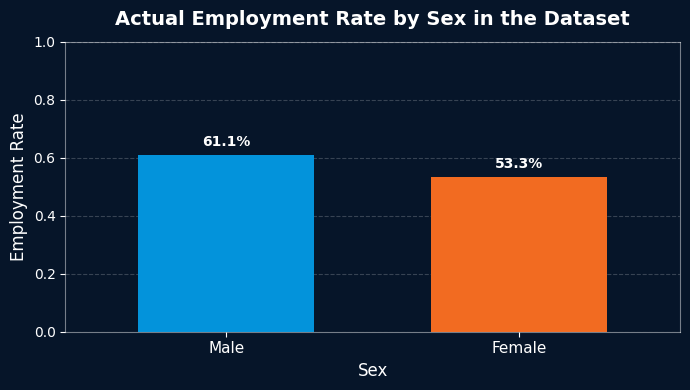

In [8]:
# poster visual

POSTER_BG = "#061529"      # using a dark preview background only for notebook
POSTER_BLUE = "#0393DB"
POSTER_ORANGE = "#F26B21"
POSTER_WHITE = "white"

color_map = {
    "Male": POSTER_BLUE,
    "Female": POSTER_ORANGE
}

bar_colors = [color_map.get(label, "#999999") for label in sex_rates.index]

fig, ax = plt.subplots(figsize=(7, 4), facecolor=POSTER_BG)
ax.set_facecolor(POSTER_BG)

sex_rates["actual_employment_rate"].plot(
    kind="bar",
    ax=ax,
    color=bar_colors,
    width=0.6
)

# Title and labels
ax.set_title(
    "Actual Employment Rate by Sex in the Dataset",
    color=POSTER_WHITE,
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Sex", color=POSTER_WHITE, fontsize=12)
ax.set_ylabel("Employment Rate", color=POSTER_WHITE, fontsize=12)

# Ticks
ax.tick_params(axis="x", colors=POSTER_WHITE, rotation=0, labelsize=11)
ax.tick_params(axis="y", colors=POSTER_WHITE, labelsize=10)

# Spines
for spine in ax.spines.values():
    spine.set_color(POSTER_WHITE)
    spine.set_alpha(0.45)

# Grid
ax.grid(axis="y", color=POSTER_WHITE, alpha=0.20, linestyle="--")
ax.set_axisbelow(True)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{bar.get_height()*100:.1f}%" for bar in container],
        color=POSTER_WHITE,
        fontsize=10,
        fontweight="bold",
        padding=4
    )

plt.ylim(0, 1)
plt.tight_layout()

# Save with transparent background for  poster
plt.savefig(
    FIGURE_DIR / "actual_employment_by_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## 8. Prepare modeling data

Please note that you need to increase `MAX_ROWS` if you want a larger analysis. Other, reduce it if the notebook is running slow.

In [9]:
MAX_ROWS = 60000

if len(df) > MAX_ROWS:
    df_model = (
        df.groupby("employment", group_keys=False)
          .apply(lambda x: x.sample(
              n=min(len(x), max(1, int(MAX_ROWS * len(x) / len(df)))),
              random_state=RANDOM_STATE
          ))
          .sample(frac=1, random_state=RANDOM_STATE)
          .copy()
    )
else:
    df_model = df.copy()

print("Modeling dataset shape:", df_model.shape)
display(df_model["employment"].value_counts(normalize=True).to_frame("proportion"))

Modeling dataset shape: (59999, 20)


,proportion
employment,
1,0.571343
0,0.428657


## Output of this notebook

The cleaned dataframe is `df`; the sampled modeling dataframe is `df_model`. Please note that these objects are rebuilt in later notebooks so each notebook can run independently in Colab.
